In [ ]:
# 라이브러리 불러오기

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## 1. 데이터 전처리


In [ ]:
# 데이터 불러오기

x_raw = np.load('X_rank3_tensor.npy')
y_raw = np.load('y_labels.npy')

In [ ]:
# 특성 그룹 정의

track_features = [
		'tempo', 'loudness', 'mode', 'danceability', 'energy',
    'speechiness', 'acousticness', 'liveness', 'happiness', 'instrumentalness'
]

numeric_features = [f for f in track_features if f != 'mode']
categorical_feature = ['mode']

# 데이터셋 분리
## 학습 데이터와 테스트 데이터로 분리
x_train, x_test, y_train, y_test = train_test_split(
    x_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

## 학습 데이터와 검증 데이터로 분리
x_train_partial, x_val, y_train_partial, y_val = train_test_split(
    x_train, y_train, test_size=0.3, random_state=42, stratify=y_train)


# 전처리 함수 정의
## LLM 참고
scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
target_encoder = OneHotEncoder()


def data_preprocessed(x_data, is_train=False):
	(n_playlists, n_tracks, n_features) = x_data.shape
	x_2d = x_data.reshape(n_playlists*n_tracks, n_features)
	x_df = pd.DataFrame(x_2d, columns=track_features)

	real_song = x_df['tempo'] > 0

	# 수치형 전처리
	if is_train:
		scaler.fit(x_df.loc[real_song, numeric_features])

	x_df.loc[real_song, numeric_features] = scaler.transform(
		x_df.loc[real_song, numeric_features]
	)

	# 범주형 전처리
	if is_train:
		encoder.fit(x_df.loc[real_song, categorical_feature])

	# 전체 변환, 패딩된 노래는 0
	mode_encoded = encoder.transform(x_df[categorical_feature])
	mode_encoded[~real_song] = 0

	# 병합
	x_numeric = x_df[numeric_features].values
	x_2d = np.concatenate([x_numeric, mode_encoded], axis=1)

	# 2d 배열을 다시 3d로 변환
	n_features = x_2d.shape[1]
	x_data = x_2d.reshape(n_playlists, n_tracks, n_features)

	return x_data

# 전처리 실행
x_train_partial = data_preprocessed(x_train_partial, is_train=True)
x_val = data_preprocessed(x_val, is_train=False)
x_test = data_preprocessed(x_test, is_train=False)

# 타깃인 MBTI 클래스 one-hot encoding
y_train_partial = target_encoder.fit_transform(y_train_partial.reshape(-1, 1)).toarray()
y_val = target_encoder.transform(y_val.reshape(-1, 1)).toarray()
y_test = target_encoder.transform(y_test.reshape(-1, 1)).toarray()

# 나중에 예측한 결과를 MBTI 문자열로 되돌릴 때 사용
# SHAP 에서도 필요함
mbti_classes = target_encoder.categories_[0]


In [ ]:
# 시각화 함수 정의
## LLM 참고

def plot_history(history, title="Model Performance"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # 정확도 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 손실 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()



## 3. 모델 정의 및 학습

- 모델 1

In [ ]:
# 기본 베이스 모델
def build_base_model():
    model = Sequential([
        Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),

        Flatten(),

        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(16, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

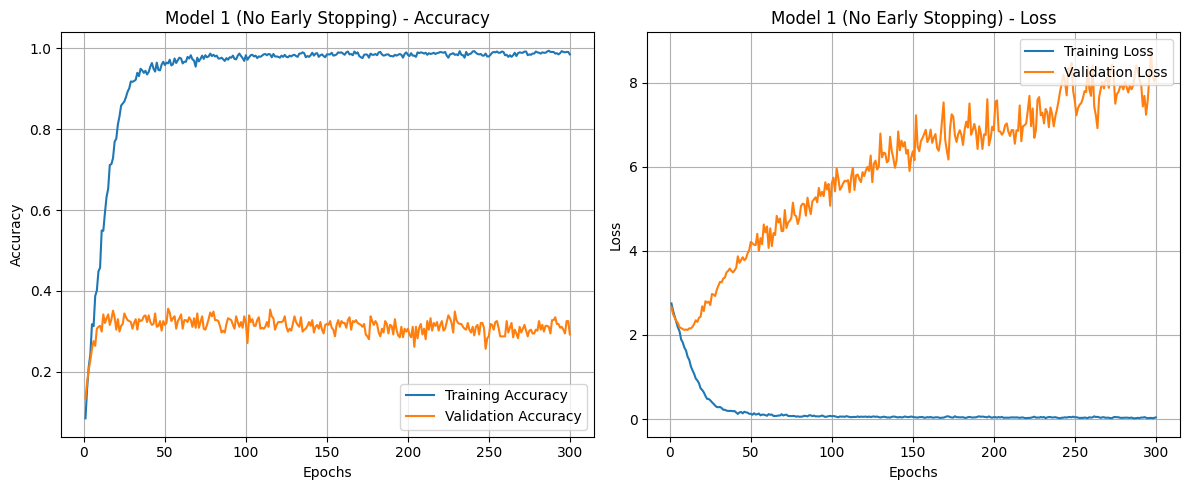

In [ ]:
## 베이스모델 학습 및 평가

## 모델1: 베이스모델, Early Stopping 미적용
model1 = build_base_model()
history1 = model1.fit(
    x_train_partial, y_train_partial,
    validation_data=(x_val, y_val),
    epochs=300,
    batch_size=32,
    verbose=0
)
plot_history(history1, title="Model 1 (No Early Stopping)")


- 모델 2

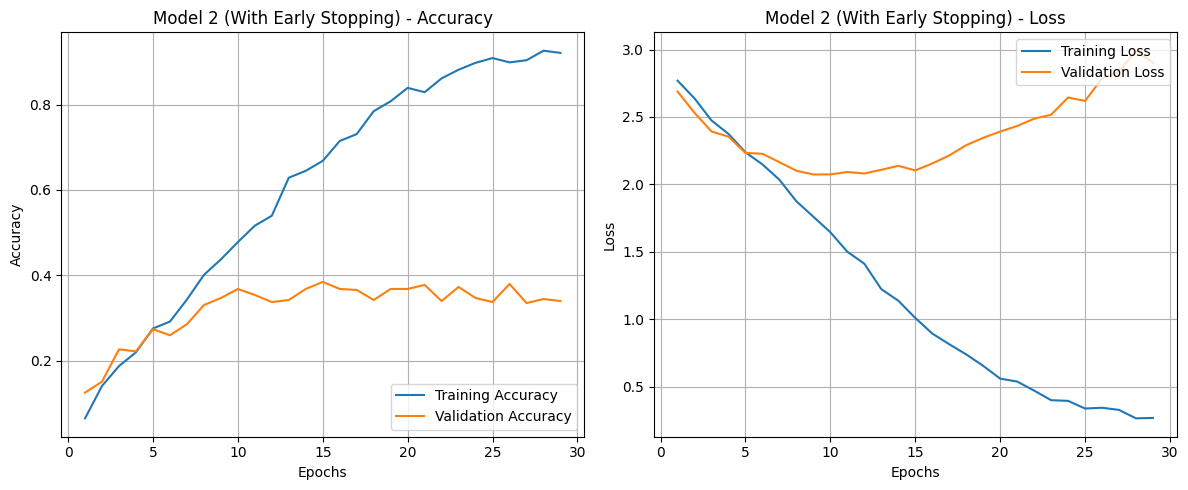

Model 2 stopped at epoch 29


In [ ]:
## 모델2: 베이스모델에 Early Stopping 적용

## early_stopping 정의
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

model2 = build_base_model()
history2 = model2.fit(
    x_train_partial, y_train_partial,
    validation_data=(x_val, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)
plot_history(history2, title="Model 2 (With Early Stopping)")
print(f"Model 2 stopped at epoch {early_stopping.stopped_epoch+1}")

- 모델 3

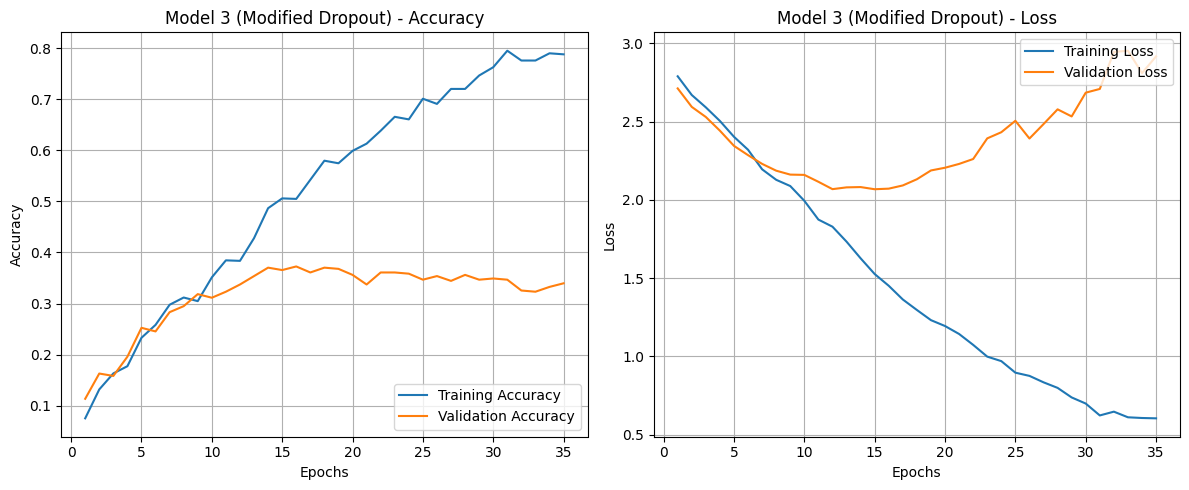

Model 3 stopped at epoch 35


In [ ]:
## 모델3: Dropout 비율 0.3 -> 0.5

def build_model():
    model = Sequential([
        Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),

        Flatten(),

        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(16, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model


model3 = build_model()

history3 = model3.fit(
    x_train_partial, y_train_partial,
    validation_data=(x_val, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)
plot_history(history3, title="Model 3 (Modified Dropout)")
print(f"Model 3 stopped at epoch {early_stopping.stopped_epoch+1}")

- 모델 4

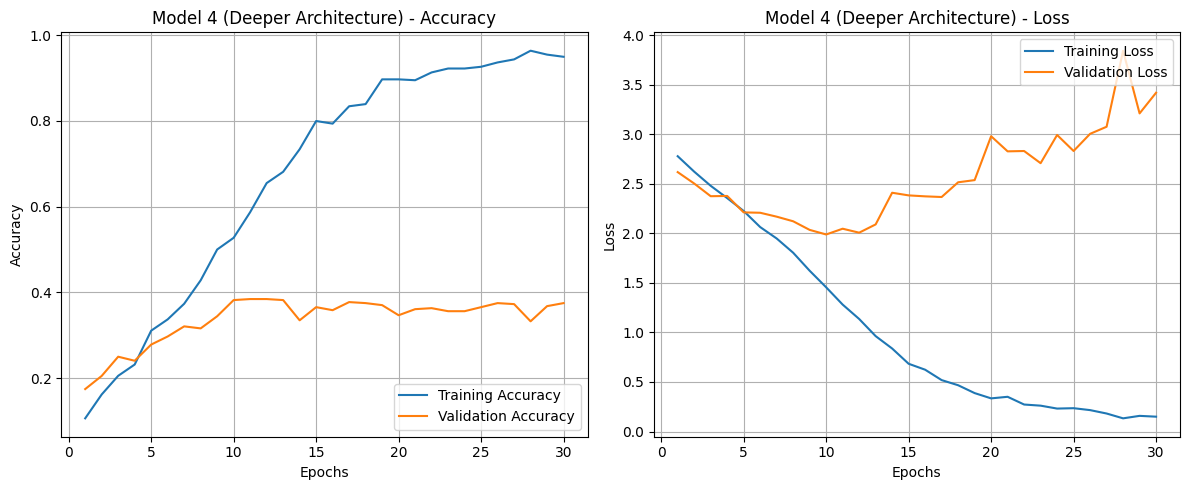

Model 4 stopped at epoch 30


In [ ]:
## 모델4: 모델 구조 및 하이퍼파라미터 조정
## Conv1D 레이어 추가, 각 레이어마다 유닛 수 조정
## 옵티마이저 adam -> rmsprop

def build_deeper_model():
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(2),
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(2),
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),

        Flatten(),

        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(16, activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

model4 = build_deeper_model()

history4 = model4.fit(
    x_train_partial, y_train_partial,
    validation_data=(x_val, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)
plot_history(history4, title="Model 4 (Deeper Architecture)")
print(f"Model 4 stopped at epoch {early_stopping.stopped_epoch+1}")

- 모델 5

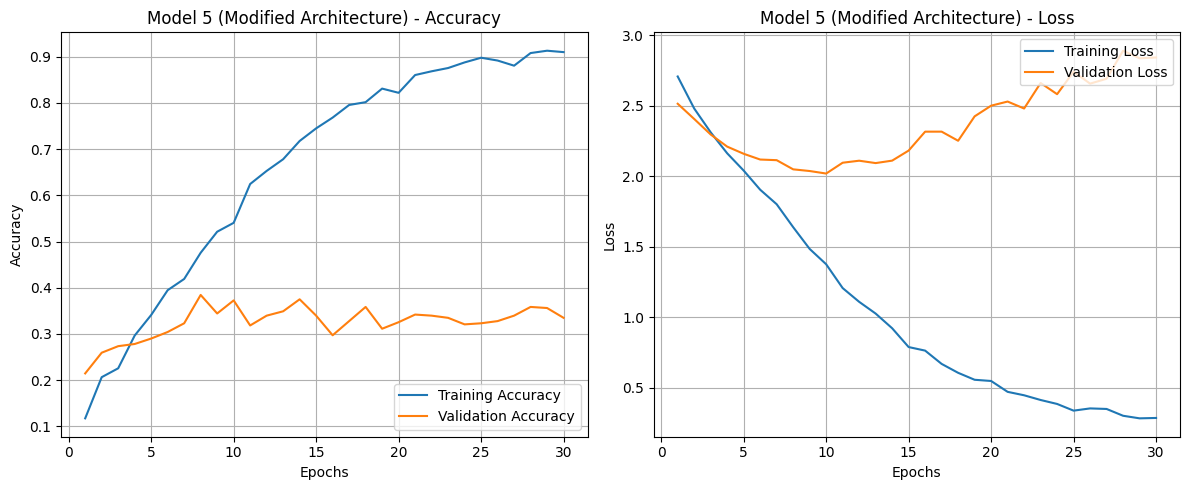

Model 5 stopped at epoch 30


In [ ]:
## 모델5: 모델 구조 변경
## 레이어 유닛 수 증가

def build_deeper_model():
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(2),
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(2),

        Flatten(),

        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(16, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

model5 = build_deeper_model()

history5 = model5.fit(
    x_train_partial, y_train_partial,
    validation_data=(x_val, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)
plot_history(history5, title="Model 5 (Modified Architecture)")
print(f"Model 5 stopped at epoch {early_stopping.stopped_epoch+1}")

Model 1 - val_loss: 8.1213, val_accuracy: 0.2925
Model 2 - val_loss: 2.0731, val_accuracy: 0.3467
Model 3 - val_loss: 2.0674, val_accuracy: 0.3656
Model 4 - val_loss: 1.9882, val_accuracy: 0.3821
Model 5 - val_loss: 2.0195, val_accuracy: 0.3726


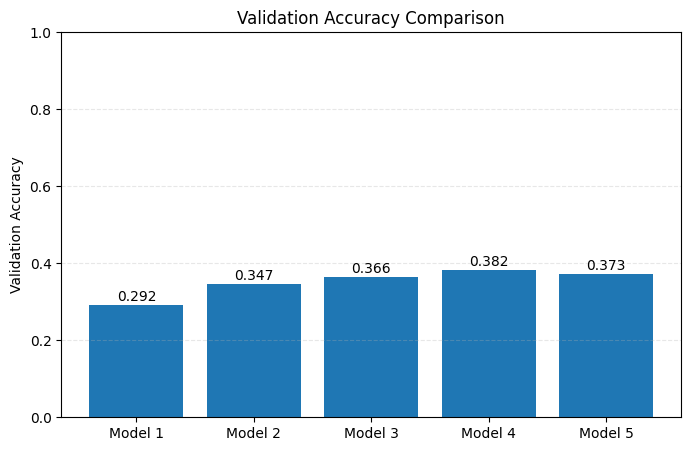

In [ ]:
# 모델 성능 비교하기
## LLM 참고

models = [model1, model2, model3, model4, model5]
model_names = ["Model 1", "Model 2", "Model 3", "Model 4", "Model 5"]

val_results = []

for name, m in zip(model_names, models):
    loss, acc = m.evaluate(x_val, y_val, verbose=0)
    val_results.append({"model": name, "val_loss": loss, "val_accuracy": acc})
    print(f"{name} - val_loss: {loss:.4f}, val_accuracy: {acc:.4f}")

df_val = pd.DataFrame(val_results)

plt.figure(figsize=(8,5))
plt.bar(df_val["model"], df_val["val_accuracy"])
plt.ylim(0, 1)
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")

for i, v in enumerate(df_val["val_accuracy"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


Train Accuracy: 0.7723
Val   Accuracy: 0.3821
Test  Accuracy: 0.3654


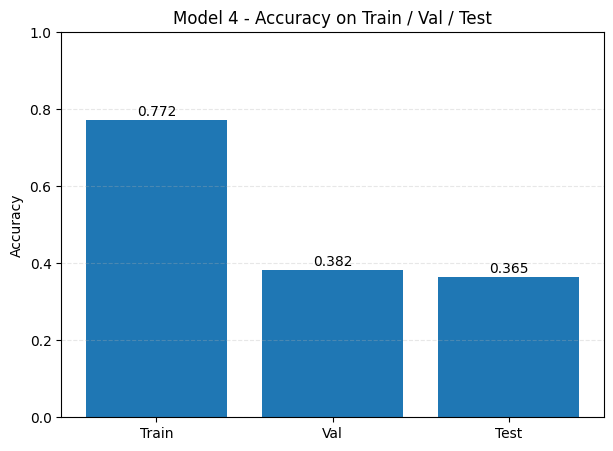

In [ ]:
# 테스트 성능 분석
train_loss, train_acc = model4.evaluate(x_train_partial, y_train_partial, verbose=0)
val_loss,   val_acc   = model4.evaluate(x_val, y_val, verbose=0)
test_loss,  test_acc  = model4.evaluate(x_test, y_test, verbose=0)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Val   Accuracy: {val_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")

# 막대그래프로 시각화
labels = ["Train", "Val", "Test"]
accs   = [train_acc, val_acc, test_acc]

plt.figure(figsize=(7,5))
plt.bar(labels, accs)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model 4 - Accuracy on Train / Val / Test")

for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## 3. SHAP 적용
- 가장 성능이 좋았던 Model 4에 적용해서 중요 특성 추출하기
- **LLM을 참고하여 작성했습니다.**


In [ ]:
!pip install shap
import shap

# 백그라운드 & 샘플 데이터
x_background = x_train_partial[:200]
x_sample = x_test[:50]

# shap 값 계산하기
explainer = shap.DeepExplainer(model4, x_background)  # 일부 샘플만 사용
shap_values = explainer.shap_values(x_sample)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_30
Received: inputs=['Tensor(shape=(200, 60, 11))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_30
Received: inputs=['Tensor(shape=(400, 60, 11))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_30
Received: inputs=['Tensor(shape=(50, 60, 11))'

In [ ]:
# shap_values: (samples, tracks, features, classes)
feature_names = ['tempo', 'loudness', 'danceability', 'energy', 'speechiness',
                 'acousticness', 'liveness', 'happiness', 'instrumentalness', 'mode 0,0', 'mode 1.0']  # 길이 11
impact_results = {}

print("shap_values.shape:", shap_values.shape)  # (50, 60, 11, 16)

for class_idx, mbti in enumerate(mbti_classes):
    # 해당 MBTI 클래스에 대한 SHAP 값
    class_shap = shap_values[:, :, :, class_idx]

    # 모든 sample + 모든 track에 대해 평균 → (features,)
    feature_importance = np.mean(np.abs(class_shap), axis=(0, 1))

    # 상위 5개 feature index
    top_idx = np.argsort(feature_importance)[::-1][:5]

    # (feature 이름, 중요도 값)
    top_features = [(feature_names[i], feature_importance[i]) for i in top_idx]
    impact_results[mbti] = top_features

print("📌 MBTI별 영향력 높은 상위 5개 특성\n")
for mbti, feats in impact_results.items():
    print(f"- {mbti}:")
    for fname, score in feats:
        print(f" + {fname}: {score:.4f}")
    print("")


shap_values.shape: (50, 60, 11, 16)
📌 MBTI별 영향력 높은 상위 5개 특성

- ENFJ:
 + happiness: 0.0182
 + acousticness: 0.0141
 + danceability: 0.0134
 + tempo: 0.0133
 + loudness: 0.0116

- ENFP:
 + danceability: 0.0107
 + happiness: 0.0102
 + tempo: 0.0076
 + liveness: 0.0075
 + speechiness: 0.0073

- ENTJ:
 + danceability: 0.0034
 + happiness: 0.0033
 + speechiness: 0.0031
 + liveness: 0.0028
 + tempo: 0.0026

- ENTP:
 + danceability: 0.0281
 + happiness: 0.0173
 + tempo: 0.0165
 + liveness: 0.0150
 + loudness: 0.0135

- ESFJ:
 + danceability: 0.0015
 + speechiness: 0.0015
 + happiness: 0.0014
 + tempo: 0.0014
 + acousticness: 0.0014

- ESFP:
 + danceability: 0.0041
 + happiness: 0.0038
 + liveness: 0.0036
 + tempo: 0.0033
 + acousticness: 0.0029

- ESTJ:
 + danceability: 0.0022
 + happiness: 0.0019
 + speechiness: 0.0016
 + tempo: 0.0015
 + liveness: 0.0015

- ESTP:
 + danceability: 0.0068
 + happiness: 0.0056
 + liveness: 0.0051
 + speechiness: 0.0049
 + tempo: 0.0048

- INFJ:
 + happiness: 0.

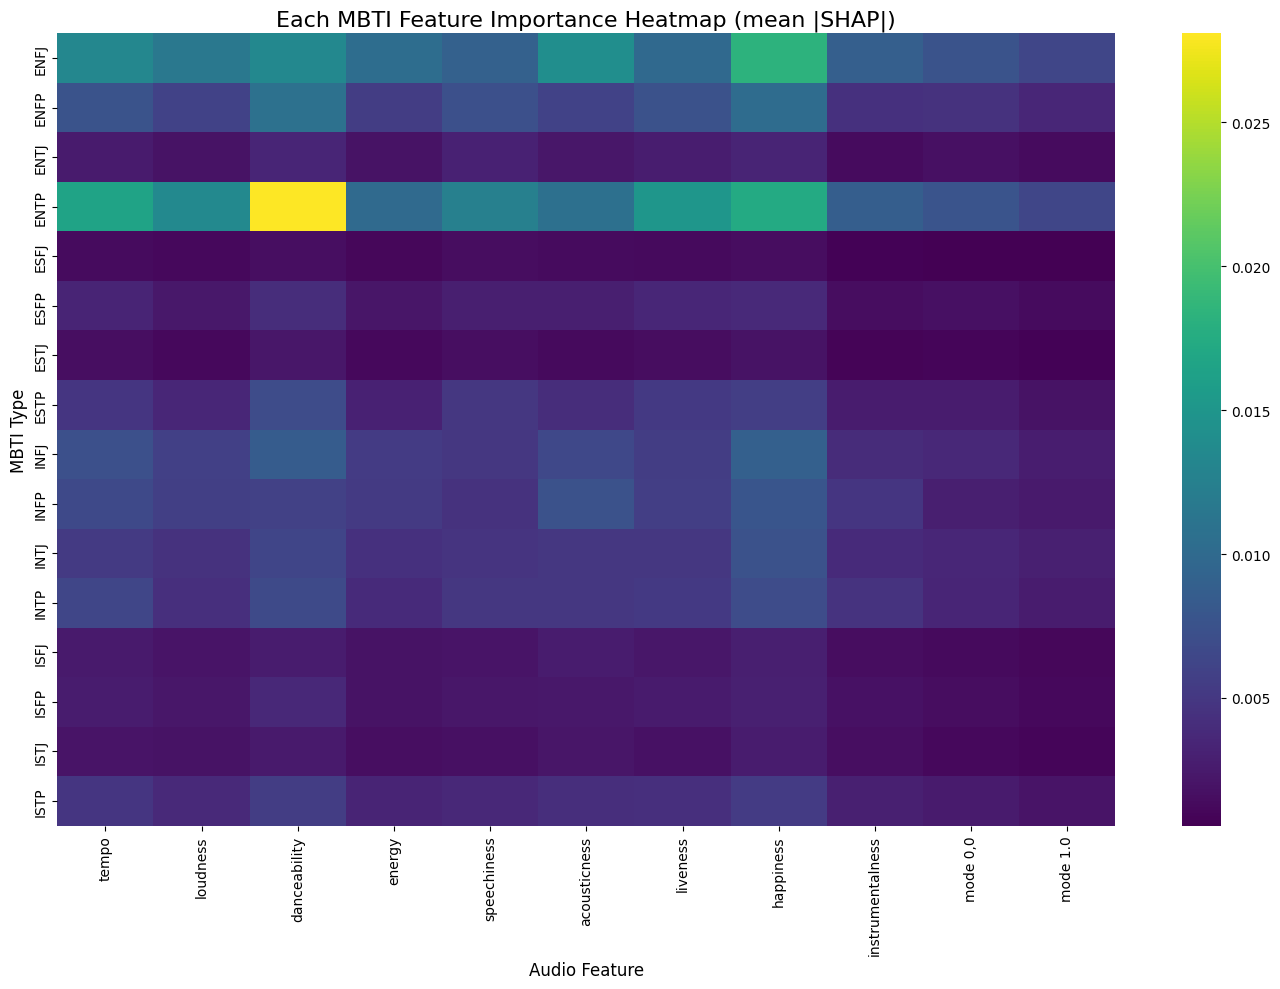

In [ ]:
# 히트맵 시각화

n_classes = len(mbti_classes)
n_features = len(feature_names)

class_shap_mean = np.zeros((n_classes, n_features))

for class_idx in range(n_classes):
    class_shap = shap_values[:, :, :, class_idx]

    fi = np.mean(np.abs(class_shap), axis=(0, 1))

    class_shap_mean[class_idx] = fi

df_heatmap = pd.DataFrame(
    class_shap_mean,
    index=mbti_classes,
    columns=feature_names
)

plt.figure(figsize=(14, 10))
sns.heatmap(df_heatmap, cmap="viridis", annot=False)
plt.title("Each MBTI Feature Importance Heatmap (mean |SHAP|)", fontsize=16)
plt.xlabel("Audio Feature", fontsize=12)
plt.ylabel("MBTI Type", fontsize=12)
plt.tight_layout()
plt.show()


## 4. K-폴드 교차 검증

In [ ]:
# 정보 누수 방지 위해 각 폴드마다 매번 전처리되도록 함
## 훈련 데이터와 테스트 데이터로 데이터 분리
x_train, x_test, y_train, y_test = train_test_split(
    x_raw, y_raw, test_size=0.2, random_state=42, shuffle=True, stratify=y_raw)

## 전처리 함수 정의

def data_preprocessed(x_data, scaler, encoder, is_train=False):
	(n_playlists, n_tracks, n_features) = x_data.shape
	x_2d = x_data.reshape(n_playlists*n_tracks, n_features)
	x_df = pd.DataFrame(x_2d, columns=track_features)

	real_song = x_df['tempo'] > 0

	# 수치형 전처리
	if is_train:
		scaler.fit(x_df.loc[real_song, numeric_features])

	x_df.loc[real_song, numeric_features] = scaler.transform(
		x_df.loc[real_song, numeric_features]
	)

	# 범주형 전처리
	if is_train:
		encoder.fit(x_df.loc[real_song, categorical_feature])

	# 전체 변환, 패딩된 노래는 0
	mode_encoded = encoder.transform(x_df[categorical_feature])
	mode_encoded[~real_song] = 0

	# 병합
	x_numeric = x_df[numeric_features].values
	x_2d = np.concatenate([x_numeric, mode_encoded], axis=1)

	# 2d 배열을 다시 3d로 변환
	n_features = x_2d.shape[1]
	x_data = x_2d.reshape(n_playlists, n_tracks, n_features)

	return x_data

In [ ]:
# K-Fold 교차 검증

from sklearn.metrics import accuracy_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

## 폴드 기록
fold_models = []
fold_val_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(x_train, y_train)):
    print(f" 📁 {fold+1}번째 폴드 훈련중")
    ## 가장 검증 정확도가 높았던 모델 채택
    kmodel = build_deeper_model()

    ## 검증 데이터셋 분리
    x_train_partial, x_val = x_train[train_idx], x_train[val_idx]
    y_train_partial, y_val = y_train[train_idx], y_train[val_idx]

    ## 데이터 전처리
    scaler = StandardScaler()
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    target_encoder = OneHotEncoder(sparse_output=False)

    ## 입력 데이터
    x_train_partial = data_preprocessed(x_train_partial, scaler, encoder, is_train=True)
    x_val = data_preprocessed(x_val, scaler, encoder, is_train=False)


    ## target
    y_train_partial = target_encoder.fit_transform(y_train_partial.reshape(-1, 1))
    y_val = target_encoder.transform(y_val.reshape(-1, 1))

    history = kmodel.fit(
        x_train_partial, y_train_partial,
        validation_data=(x_val, y_val),
        epochs=500,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    ## 성능 평가
    val_pred = kmodel.predict(x_val, verbose=0)
    val_acc = accuracy_score(np.argmax(y_val, axis=1), np.argmax(val_pred, axis=1))

    print(f"{fold+1}번째 폴드 검증 정확도: {val_acc:.4f}")


    fold_models.append(kmodel)
    fold_val_scores.append(val_acc)

print("평균 K-Fold 정확도: ", np.mean(fold_val_scores))

 📁 1번째 폴드 훈련중
1번째 폴드 검증 정확도: 0.3322
 📁 2번째 폴드 훈련중
2번째 폴드 검증 정확도: 0.3887
 📁 3번째 폴드 훈련중
3번째 폴드 검증 정확도: 0.3972
 📁 4번째 폴드 훈련중
4번째 폴드 검증 정확도: 0.3972
 📁 5번째 폴드 훈련중
5번째 폴드 검증 정확도: 0.4043
평균 K-Fold 정확도:  0.3838859233641581
